# TT-07 — Gradient Boosting: Dự đoán thu nhập > 50K

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier, HistGradientBoostingClassifier,
    RandomForestClassifier, AdaBoostClassifier,
)
from sklearn.metrics import average_precision_score, roc_auc_score, accuracy_score, log_loss
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_DIR = "../dataset"  
pd.set_option('display.max_columns', 50)

COLS = ["age", "workclass", "fnlwgt", "education", "education-num",
        "marital-status", "occupation", "relationship", "race", "sex",
        "capital-gain", "capital-loss", "hours-per-week", "native-country",
        "income"]

## 1. Đọc dữ liệu & xử lý 4 bẫy

In [18]:
def clean_raw(df):
    str_cols = df.select_dtypes(include="object").columns
    for c in str_cols:
        df[c] = df[c].str.strip()
    df = df.replace("?", np.nan)
    df = df.drop(columns=["education", "fnlwgt"])
    df["income"] = df["income"].str.replace(".", "", regex=False)
    return df

train_df = pd.read_csv(f"{DATA_DIR}/adult.data", names=COLS, sep=r",\s*",
                        engine="python", na_values="?")
test_df = pd.read_csv(f"{DATA_DIR}/adult.test", names=COLS, sep=r",\s*",
                       engine="python", na_values="?", skiprows=1)

train_df, test_df = clean_raw(train_df), clean_raw(test_df)
print("Train:", train_df.shape, "| Test:", test_df.shape)
train_df.head()

Train: (32561, 13) | Test: (16281, 13)


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. EDA — tỉ lệ >50K theo học vấn, giờ làm, hôn nhân

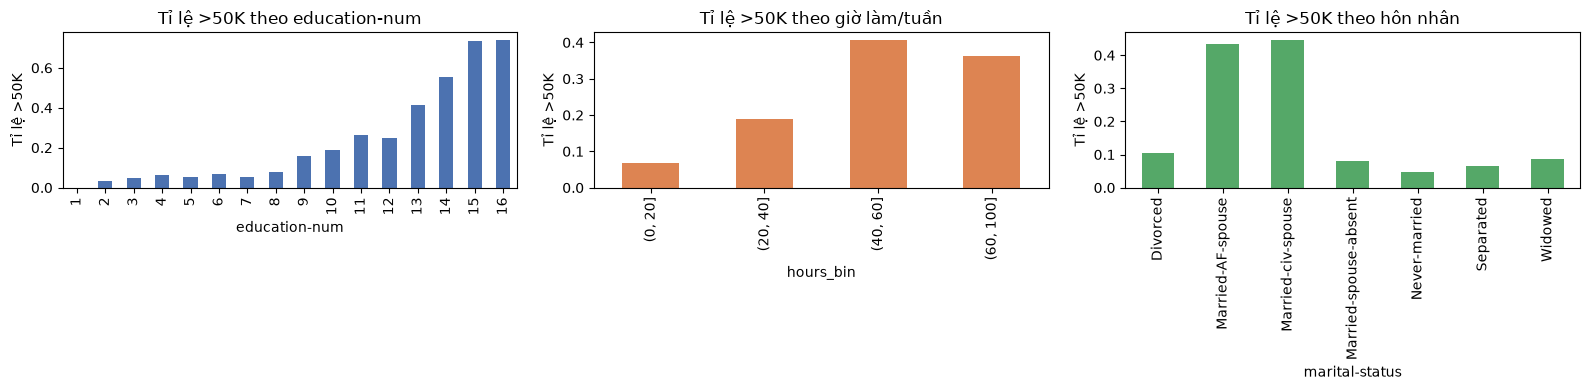

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

train_df.groupby("education-num")["income"].apply(lambda s: (s == ">50K").mean()).plot(
    kind="bar", ax=axes[0], title="Tỉ lệ >50K theo education-num", color="#4C72B0")

train_df.assign(hours_bin=pd.cut(train_df["hours-per-week"], [0,20,40,60,100])).groupby(
    "hours_bin", observed=True)["income"].apply(lambda s: (s==">50K").mean()).plot(
    kind="bar", ax=axes[1], title="Tỉ lệ >50K theo giờ làm/tuần", color="#DD8452")

train_df.groupby("marital-status")["income"].apply(lambda s: (s==">50K").mean()).plot(
    kind="bar", ax=axes[2], title="Tỉ lệ >50K theo hôn nhân", color="#55A868")

for ax in axes:
    ax.set_ylabel("Tỉ lệ >50K")
plt.tight_layout()
plt.show()

## 3. `capital-gain` lệch cực đoan

0.9167101747489328 giá trị bằng 0


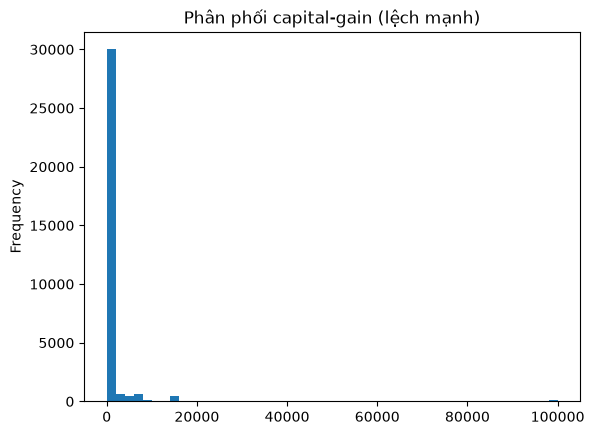

In [20]:
print((train_df["capital-gain"] == 0).mean(), "giá trị bằng 0")
train_df["capital-gain"].plot(kind="hist", bins=50, title="Phân phối capital-gain (lệch mạnh)")
plt.show()

## 4. Chuẩn bị X, y và pipeline

> Boosting dựa trên cây quyết định nên **không cần chuẩn hoá (scale)** biến số.

In [21]:
y_train = (train_df["income"] == ">50K").astype(int)
X_train = train_df.drop(columns=["income"])
y_test = (test_df["income"] == ">50K").astype(int)
X_test = test_df.drop(columns=["income"])

def build_pipeline(X, model):
    cat_cols = X.select_dtypes(include="object").columns.tolist()
    num_cols = X.select_dtypes(exclude="object").columns.tolist()
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", "passthrough", num_cols),
    ])
    return Pipeline([("pre", pre), ("model", model)])

## 5. Baseline: Dummy & Decision Tree

In [22]:
baselines = {
    "Dummy (most_frequent)": DummyClassifier(strategy="most_frequent"),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
}
rows = []
for name, model in baselines.items():
    pipe = build_pipeline(X_train, model)
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({"model": name, "roc_auc": roc_auc_score(y_test, proba),
                 "pr_auc": average_precision_score(y_test, proba)})
pd.DataFrame(rows)

,model,roc_auc,pr_auc
0,Dummy (most_frequent),0.500000,0.236226
1,Decision Tree,0.895448,0.723033


## 6. Gradient Boosting

In [23]:
gb = GradientBoostingClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=3,
    subsample=0.8, validation_fraction=0.1, n_iter_no_change=20,
    random_state=RANDOM_STATE,
)
gb_pipe = build_pipeline(X_train, gb)
gb_pipe.fit(X_train, y_train)

proba = gb_pipe.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC :", average_precision_score(y_test, proba))

ROC-AUC: 0.9241455359862967
PR-AUC : 0.8188335786200441


## 7. Train/Validation loss theo số cây → điểm bắt đầu overfit

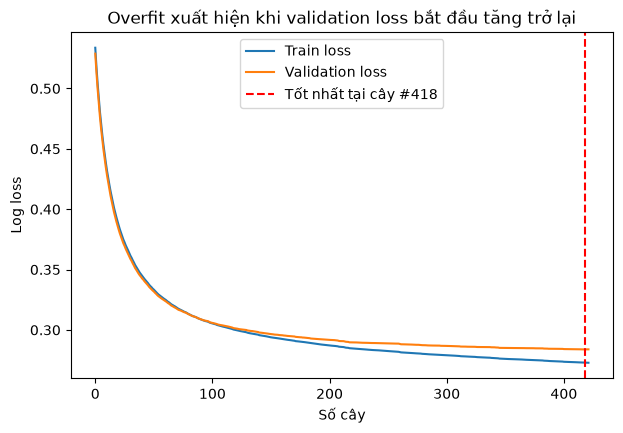

Sau cây #418, train loss tiếp tục giảm nhưng validation loss tăng -> overfit.


In [24]:
pre = gb_pipe.named_steps["pre"]
model = gb_pipe.named_steps["model"]
Xtr, Xte = pre.transform(X_train), pre.transform(X_test)

train_loss = [log_loss(y_train, p) for p in model.staged_predict_proba(Xtr)]
test_loss = [log_loss(y_test, p) for p in model.staged_predict_proba(Xte)]
best_iter = int(np.argmin(test_loss))

plt.figure(figsize=(7,4.5))
plt.plot(train_loss, label="Train loss")
plt.plot(test_loss, label="Validation loss")
plt.axvline(best_iter, color="red", ls="--", label=f"Tốt nhất tại cây #{best_iter}")
plt.xlabel("Số cây"); plt.ylabel("Log loss"); plt.legend()
plt.title("Overfit xuất hiện khi validation loss bắt đầu tăng trở lại")
plt.show()
print(f"Sau cây #{best_iter}, train loss tiếp tục giảm nhưng validation loss tăng -> overfit.")

## 8. Dò learning_rate × n_estimators (lưới 3×3) → chứng minh quan hệ nghịch

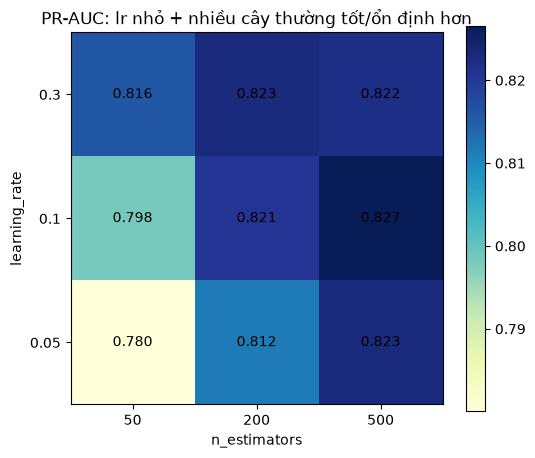

In [25]:
lrs, n_ests = [0.3, 0.1, 0.05], [50, 200, 500]
grid = np.zeros((len(lrs), len(n_ests)))
for i, lr in enumerate(lrs):
    for j, n in enumerate(n_ests):
        m = GradientBoostingClassifier(n_estimators=n, learning_rate=lr, max_depth=3,
                                        random_state=RANDOM_STATE)
        p = build_pipeline(X_train, m)
        p.fit(X_train, y_train)
        grid[i, j] = average_precision_score(y_test, p.predict_proba(X_test)[:, 1])

plt.figure(figsize=(6,5))
plt.imshow(grid, cmap="YlGnBu")
plt.xticks(range(len(n_ests)), n_ests); plt.yticks(range(len(lrs)), lrs)
plt.xlabel("n_estimators"); plt.ylabel("learning_rate")
for i in range(len(lrs)):
    for j in range(len(n_ests)):
        plt.text(j, i, f"{grid[i,j]:.3f}", ha="center", va="center")
plt.title("PR-AUC: lr nhỏ + nhiều cây thường tốt/ổn định hơn")
plt.colorbar()
plt.show()

## 9. So sánh Random Forest vs Gradient Boosting vs AdaBoost

In [26]:
import time
compare = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": gb,
    "AdaBoost": AdaBoostClassifier(n_estimators=300, learning_rate=0.5, random_state=RANDOM_STATE),
}
rows = []
for name, model in compare.items():
    pipe = build_pipeline(X_train, model)
    t0 = time.time()
    pipe.fit(X_train, y_train)
    dt = time.time() - t0
    proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({"model": name, "pr_auc": average_precision_score(y_test, proba),
                 "roc_auc": roc_auc_score(y_test, proba), "train_time_s": dt})
pd.DataFrame(rows).sort_values("pr_auc", ascending=False)

,model,pr_auc,roc_auc,train_time_s
1,Gradient Boosting,0.818834,0.924146,22.713945
2,AdaBoost,0.785440,0.911565,17.777559
0,Random Forest,0.743440,0.893914,1.746842


## 10. Đo thời gian: GradientBoosting vs HistGradientBoosting

In [27]:
hgb = HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05,
                                      early_stopping=True, random_state=RANDOM_STATE)
hgb_pipe = build_pipeline(X_train, hgb)

t0 = time.time(); gb_pipe.fit(X_train, y_train); t_gb = time.time() - t0
t0 = time.time(); hgb_pipe.fit(X_train, y_train); t_hgb = time.time() - t0

print(f"GradientBoosting:     {t_gb:.2f}s")
print(f"HistGradientBoosting: {t_hgb:.2f}s  ({t_gb/max(t_hgb,1e-9):.1f}x nhanh hơn)")

GradientBoosting:     30.53s
HistGradientBoosting: 1.50s  (20.4x nhanh hơn)


## 11. Kiểm tra thiên lệch theo `sex` và `race`

,group,n,predicted_positive_rate,actual_positive_rate,avg_predicted_probability
0,Male,10860,0.249079,0.299816,0.298961
1,Female,5421,0.078399,0.108836,0.112429


,group,n,predicted_positive_rate,actual_positive_rate,avg_predicted_probability
0,Black,1561,0.080077,0.114670,0.126301
1,White,13946,0.205148,0.250251,0.250413
2,Asian-Pac-Islander,480,0.243750,0.277083,0.264410
3,Other,135,0.088889,0.185185,0.143677
4,Amer-Indian-Eskimo,159,0.094340,0.119497,0.128694


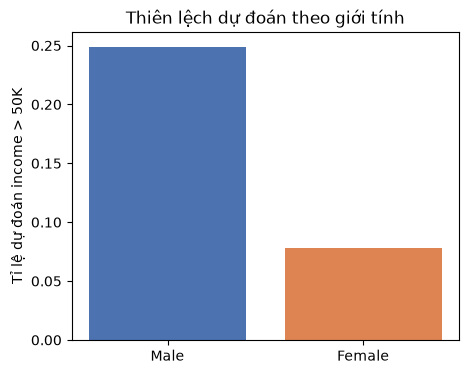

In [28]:
def bias_table(pipe, X_test, y_test, col):
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    out = []
    for g in X_test[col].dropna().unique():
        mask = X_test[col] == g
        if mask.sum() < 20:
            continue
        out.append({
            "group": g, "n": int(mask.sum()),
            "predicted_positive_rate": pred[mask].mean(),
            "actual_positive_rate": y_test[mask].mean(),
            "avg_predicted_probability": proba[mask].mean(),
        })
    return pd.DataFrame(out)

display(bias_table(gb_pipe, X_test, y_test, "sex"))
display(bias_table(gb_pipe, X_test, y_test, "race"))
bt = bias_table(gb_pipe, X_test, y_test, "sex")
plt.figure(figsize=(5,4))
plt.bar(bt["group"], bt["predicted_positive_rate"], color=["#4C72B0", "#DD8452"])
plt.ylabel("Tỉ lệ dự đoán income > 50K")
plt.title("Thiên lệch dự đoán theo giới tính")
plt.show()